# Notebook 13 – Exploratory Data Analysis (EDA) Report
## Telecom Customer Churn Dataset

This notebook presents a complete exploratory data analysis of the telecom customer churn dataset. It documents the dataset's structure, data quality issues, statistical characteristics, relationships between variables, and key visual insights.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
df = pd.read_csv('telecom_customer_churn.csv')
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 1. Dataset Overview

- **Dataset source:** Provided CSV file `telecom_customer_churn.csv` (customer-level telecom subscription and billing records; source/collection system not documented in the file itself).
- **Domain:** Telecommunications — customer retention / churn analysis.
- **Target variable:** `churn` (binary: `Yes` / `No`) — whether the customer has left the service.
- **Unit of observation:** one row per customer (identified by `customer_id`).


In [6]:
print("Shape (rows, columns):", df.shape)
print()
print("Columns and dtypes:")
df.dtypes

Shape (rows, columns): (1015, 14)

Columns and dtypes:


customer_id              str
gender                   str
senior_citizen         int64
partner                  str
dependents               str
tenure_months        float64
phone_service            str
internet_service         str
contract                 str
paperless_billing        str
payment_method           str
monthly_charges      float64
total_charges        float64
churn                    str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1015 non-null   str    
 1   gender             1015 non-null   str    
 2   senior_citizen     1015 non-null   int64  
 3   partner            1015 non-null   str    
 4   dependents         1015 non-null   str    
 5   tenure_months      1005 non-null   float64
 6   phone_service      1015 non-null   str    
 7   internet_service   995 non-null    str    
 8   contract           1015 non-null   str    
 9   paperless_billing  1015 non-null   str    
 10  payment_method     1000 non-null   str    
 11  monthly_charges    1015 non-null   float64
 12  total_charges      985 non-null    float64
 13  churn              1015 non-null   str    
dtypes: float64(3), int64(1), str(10)
memory usage: 168.7 KB


**Features (13 predictors + 1 target):**

| Column | Type (as loaded) | Description |
|---|---|---|
| customer_id | object | Unique customer identifier |
| gender | object | Customer gender |
| senior_citizen | int64 | 1 = senior citizen, 0 = not |
| partner | object | Has a partner (Yes/No) |
| dependents | object | Has dependents (Yes/No) |
| tenure_months | float64 | Months the customer has stayed |
| phone_service | object | Has phone service (Yes/No) |
| internet_service | object | Type of internet service (DSL / Fiber optic / No) |
| contract | object | Contract type (Month-to-month / One year / Two year) |
| paperless_billing | object | Paperless billing (Yes/No) |
| payment_method | object | Payment method |
| monthly_charges | float64 | Monthly bill amount |
| total_charges | float64 | Total amount billed to date |
| **churn** | object | **Target** — customer churned (Yes/No) |


## 2. Data Quality

This section checks for missing values, duplicate records, invalid values, and data-type problems.


### 2.1 Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_count', ascending=False)

,missing_count,missing_pct
total_charges,30,2.96
internet_service,20,1.97
payment_method,15,1.48
tenure_months,10,0.99


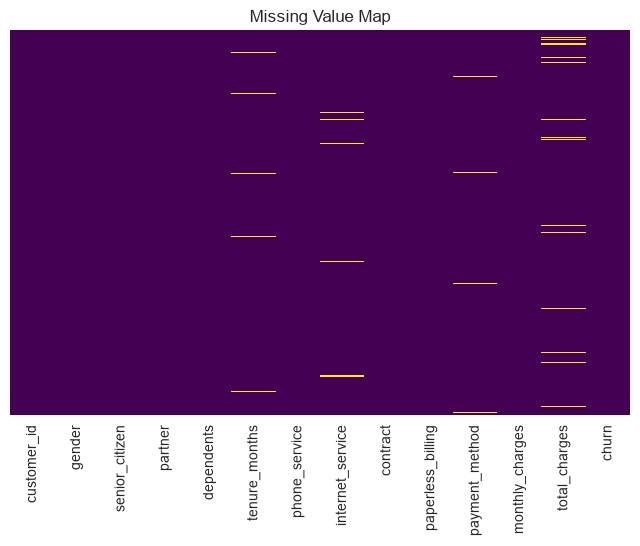

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map')
plt.show()


### 2.2 Duplicate Records

In [10]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customer_id values:", df['customer_id'].duplicated().sum())
df[df.duplicated(keep=False)].sort_values('customer_id').head(10)


Fully duplicated rows: 15
Duplicated customer_id values: 15


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
732,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
845,CUST-10049,Female,0,No,No,22.0,Yes,DSL,Month-to-month,Yes,Electronic check,88.60,1959.72,No
274,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
488,CUST-10142,Male,0,Yes,No,38.0,Yes,Fiber optic,One year,Yes,Electronic check,46.90,1762.33,No
93,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
801,CUST-10242,Male,1,No,No,67.0,Yes,Fiber optic,One year,Yes,Mailed check,119.45,8031.71,No
103,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
768,CUST-10262,Male,0,No,No,17.0,Yes,No,One year,No,Bank transfer,102.41,1722.17,Yes
75,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes
810,CUST-10318,Female,0,Yes,No,34.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,49.19,1675.96,Yes


### 2.3 Invalid Values

Checking numeric columns for values that are impossible in the real world (e.g. negative charges, negative tenure), and categorical columns for inconsistent labels.


In [11]:
print("Negative tenure_months:", (df['tenure_months'] < 0).sum())
print("Negative monthly_charges:", (df['monthly_charges'] < 0).sum())
print("Negative total_charges:", (df['total_charges'] < 0).sum())
print()
df[df['monthly_charges'] < 0][['customer_id', 'monthly_charges']]

Negative tenure_months: 0
Negative monthly_charges: 3
Negative total_charges: 0



,customer_id,monthly_charges
443,CUST-10221,-97.93
782,CUST-10576,-20.30
917,CUST-10130,-84.27


In [12]:
cat_cols = ['gender', 'partner', 'dependents', 'phone_service', 'internet_service',
            'contract', 'paperless_billing', 'payment_method', 'churn']
for c in cat_cols:
    print(f"{c}: {sorted(df[c].dropna().unique().tolist())}")

gender: ['F', 'Female', 'M', 'Male', 'female', 'male']
partner: ['N', 'No', 'Y', 'Yes', 'no', 'yes']
dependents: ['No', 'Yes']
phone_service: ['No', 'Yes']
internet_service: ['DSL', 'Fiber optic', 'No']
contract: ['Month-to-month', 'One year', 'Two year']
paperless_billing: ['N', 'No', 'Y', 'Yes', 'no', 'yes']
payment_method: ['Bank transfer', 'Credit card', 'Electronic check', 'Mailed check']
churn: ['No', 'Yes']


**Inconsistent categorical labels found:**
- `gender`: mixes `Male`/`Female` with `male`/`female`/`M`/`F` — these represent only 2 real categories but appear as 6 distinct string values.
- `partner`: mixes `Yes`/`No` with `yes`/`no`/`Y`/`N` — again 2 real categories showing as 6 values.
- `paperless_billing`: same Yes/No casing/abbreviation inconsistency (6 distinct values for 2 categories).

These will inflate cardinality counts and break any grouping/encoding step until normalized.


### 2.4 Data-Type Issues

In [13]:
df.dtypes


customer_id              str
gender                   str
senior_citizen         int64
partner                  str
dependents               str
tenure_months        float64
phone_service            str
internet_service         str
contract                 str
paperless_billing        str
payment_method           str
monthly_charges      float64
total_charges        float64
churn                    str
dtype: object

- `senior_citizen` is stored as `int64` (0/1) but is conceptually a categorical/boolean flag, not a numeric quantity — it should not be treated as continuous in statistical summaries.
- `tenure_months` is stored as `float64` even though tenure in months is naturally an integer count; this is a side effect of missing values (NaN forces float dtype).
- `customer_id` is a free-text identifier and should never be used as a model feature.
- All other categorical columns (`gender`, `partner`, `dependents`, `phone_service`, `internet_service`, `contract`, `paperless_billing`, `payment_method`, `churn`) are stored as generic `object`/string type and will need explicit categorical encoding before modeling.


## 3. Statistical Findings

Central tendency, dispersion, distribution shape, and outliers for the numeric features.


In [14]:
numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
tenure_months,1005.0,34.259701,21.137597,0.00,16.000,34.00,52.00,72.00
monthly_charges,1015.0,69.294039,30.125169,-97.93,44.395,70.09,94.37,119.45
total_charges,985.0,2360.987442,1883.592371,0.00,867.590,1849.21,3486.55,8354.36


In [16]:
print("Skewness:")
print(df[numeric_cols].skew())
print()
print("Kurtosis:")
print(df[numeric_cols].kurtosis())

Skewness:
tenure_months      0.068314
monthly_charges   -0.301960
total_charges      0.943583
dtype: float64

Kurtosis:
tenure_months     -1.214335
monthly_charges    0.288422
total_charges      0.167045
dtype: float64


**Central tendency & dispersion:**
- `tenure_months`: mean ≈ 34.3, median = 34.0 — roughly symmetric, customers range from brand-new (0 months) to 72 months.
- `monthly_charges`: mean ≈ 69.3, median ≈ 70.1 — fairly symmetric, but the presence of negative values (see Data Quality) distorts the true minimum.
- `total_charges`: mean ≈ 2361, median ≈ 1849 — right-skewed (mean > median), consistent with a skewness value close to 1, reflecting that total charges accumulate with tenure and a few long-tenured customers pull the distribution's tail to the right.

**Distribution shape:**
- `tenure_months` is close to symmetric with high dispersion (std ≈ 21 months relative to a 0–72 range).
- `monthly_charges` shows a mild left skew, partly driven by the invalid negative entries.
- `total_charges` is clearly right-skewed, which is expected since it is a cumulative product of tenure × monthly charges.


### 3.1 Outlier Detection (IQR method)

In [17]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper
for c in numeric_cols:
    outliers, lo, hi = iqr_outliers(df[c].dropna())
    print(f"{c}: bounds=({lo:.2f}, {hi:.2f}) -> {len(outliers)} outlier(s)")

tenure_months: bounds=(-38.00, 106.00) -> 0 outlier(s)
monthly_charges: bounds=(-30.57, 169.33) -> 2 outlier(s)
total_charges: bounds=(-3060.85, 7414.99) -> 12 outlier(s)


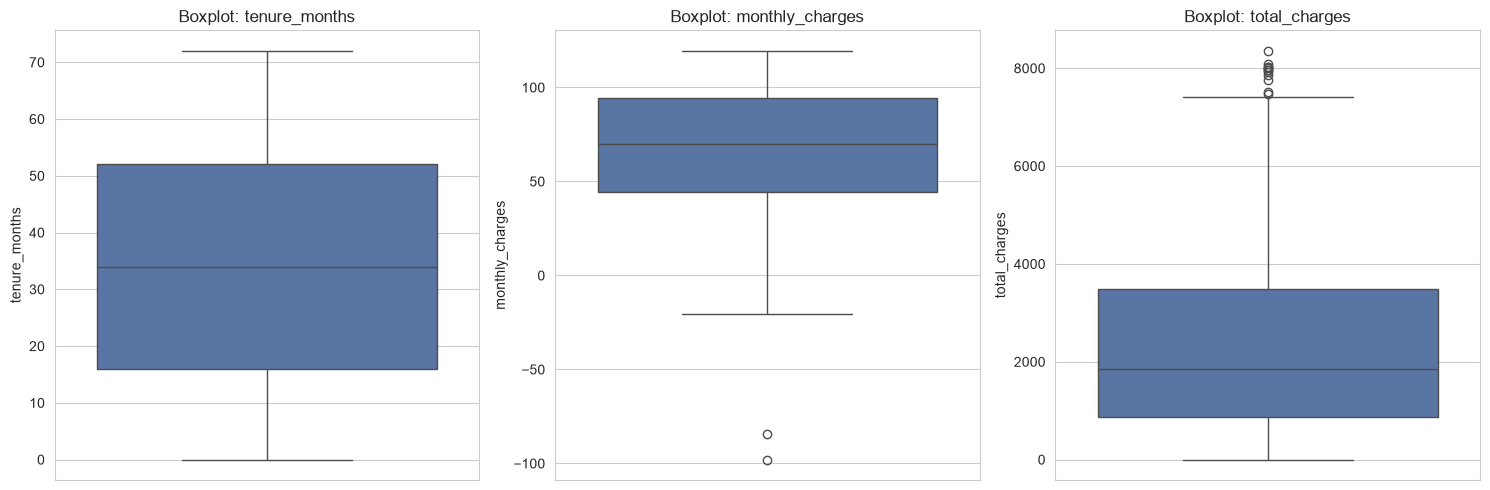

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, numeric_cols):
    sns.boxplot(y=df[c], ax=ax, color='#4C72B0')
    ax.set_title(f'Boxplot: {c}')
plt.tight_layout()
plt.show()


- `monthly_charges`: 2 outliers, both driven by the invalid negative values noted in Data Quality — not genuine high/low billing outliers.
- `total_charges`: 12 outliers on the high end, consistent with the right-skew — these are plausible (long-tenured, high-paying customers) rather than data errors, but should be reviewed before deciding on a treatment (cap, transform, or keep).
- `tenure_months`: no IQR outliers — the distribution is well-behaved.


## 4. Relationship Findings

Correlations between numeric features, and how features relate to the churn target.


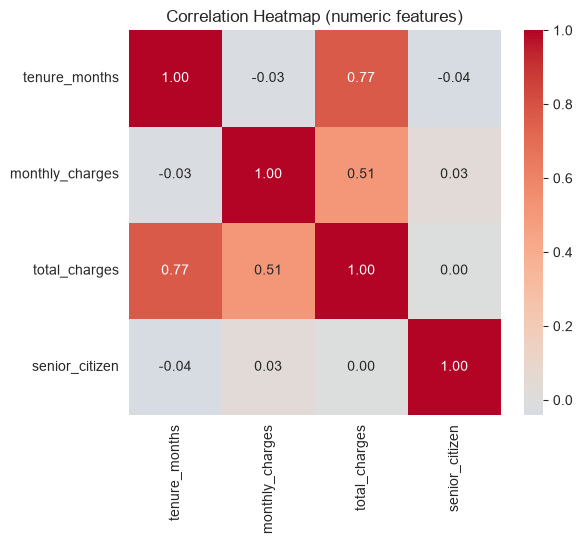

,tenure_months,monthly_charges,total_charges,senior_citizen
tenure_months,1.000000,-0.028202,0.766786,-0.041297
monthly_charges,-0.028202,1.000000,0.511545,0.033465
total_charges,0.766786,0.511545,1.000000,0.003306
senior_citizen,-0.041297,0.033465,0.003306,1.000000


In [19]:
corr = df[numeric_cols + ['senior_citizen']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features)')
plt.show()
corr


**Correlations:**
- `tenure_months` and `total_charges` are strongly positively correlated (~0.77) — expected, since total charges accumulate over time.
- `monthly_charges` and `total_charges` are moderately correlated (~0.51).
- `tenure_months` and `monthly_charges` are essentially uncorrelated (~-0.03).
- `senior_citizen` shows negligible linear correlation with the other numeric features.

This means `total_charges` carries redundant information that is largely reconstructable from `tenure_months` and `monthly_charges`, which is worth keeping in mind for feature selection.


Overall churn rate:
churn
No     0.6867
Yes    0.3133
Name: proportion, dtype: float64


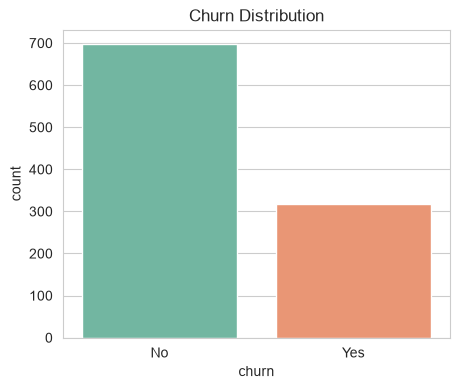

In [20]:
print("Overall churn rate:")
print(df['churn'].value_counts(normalize=True).round(4))
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='churn', hue='churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.show()

In [21]:
churn_by_contract = df.groupby('contract')['churn'].value_counts(normalize=True).unstack().fillna(0)
churn_by_contract


churn,No,Yes
contract,,
Month-to-month,0.547406,0.452594
One year,0.859438,0.140562
Two year,0.855072,0.144928


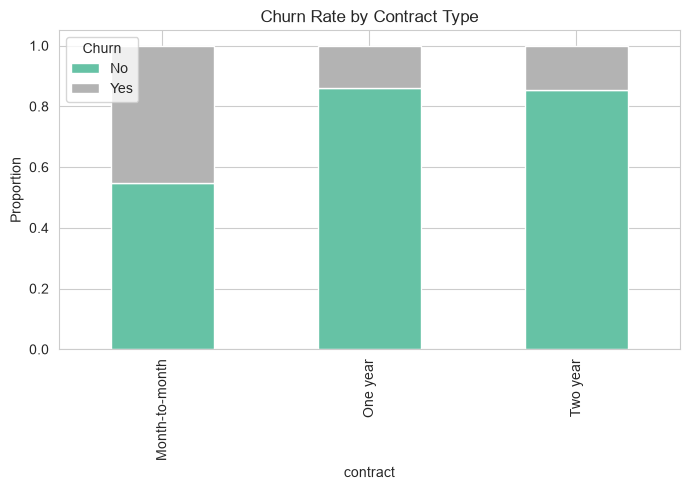

In [22]:
churn_by_contract.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set2')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Feature relationships / important patterns:**
- Overall churn rate is about **31%** (imbalanced but not extreme).
- **Contract type is strongly associated with churn**: month-to-month customers churn far more often (~45%) than one-year (~14%) or two-year (~14%) contract holders. This is the clearest behavioral pattern in the dataset.
- The near-1:1 gap between month-to-month and longer contracts suggests `contract` will likely be one of the most predictive features for a churn model.


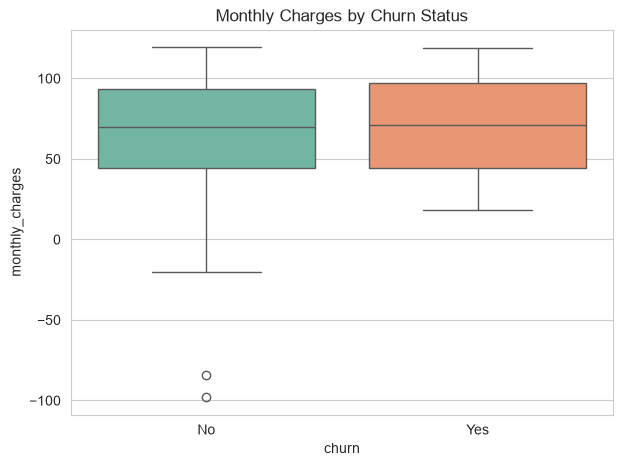

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='churn', y='monthly_charges', hue='churn', palette='Set2', legend=False)
plt.title('Monthly Charges by Churn Status')
plt.show()

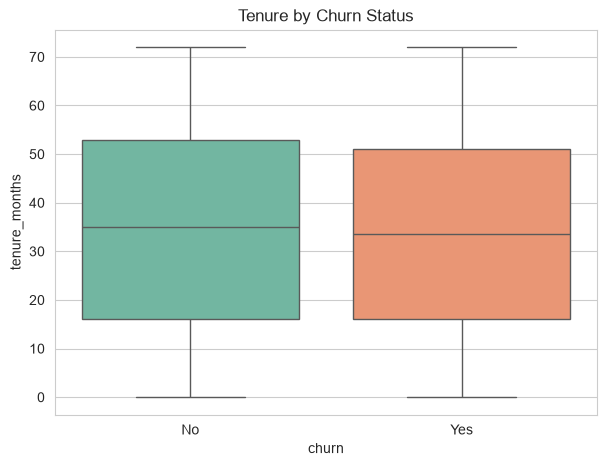

In [25]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='churn', y='tenure_months', hue='churn', palette='Set2', legend=False)
plt.title('Tenure by Churn Status')
plt.show()

- Customers who churn tend to have **higher monthly charges** and **shorter tenure** than those who stay — consistent with the contract-type pattern (new, month-to-month, higher-paying customers churn more).


## 5. Visualization Findings (Summary)

Key takeaways from the plots above:

1. **Missing-value heatmap** shows scattered gaps in `tenure_months`, `internet_service`, `payment_method`, and `total_charges` — no obvious block pattern, suggesting missingness is likely random rather than systematic (but should be verified further in preprocessing).
2. **Boxplots** confirm `total_charges` is right-skewed with a handful of high-value outliers, while `monthly_charges`' only "outliers" are the invalid negative entries, not real extreme values.
3. **Churn distribution** confirms a moderate class imbalance (~69% No / ~31% Yes) — worth accounting for during model training (e.g. stratified splits, class weighting).
4. **Contract type vs. churn** is the strongest visual pattern in the dataset — month-to-month customers churn at roughly 3x the rate of longer-contract customers.
5. **Monthly charges and tenure vs. churn** boxplots reinforce that churners skew toward higher bills and shorter relationships with the company.
6. **Correlation heatmap** shows `total_charges` is highly derivable from `tenure_months` and `monthly_charges`, flagging potential redundancy.


## 6. Potential Data Problems (for next preprocessing sprint)

| # | Issue | Affected Column(s) | Detail |
|---|---|---|---|
| 1 | Missing values | `tenure_months`, `internet_service`, `payment_method`, `total_charges` | 10, 20, 15, and 30 missing values respectively (~1–3% each) |
| 2 | Duplicate rows | All columns | 15 fully duplicated rows (also 15 duplicated `customer_id`s) |
| 3 | Invalid negative values | `monthly_charges` | 3 rows with negative charges, which is not physically possible |
| 4 | Inconsistent categorical labels | `gender`, `partner`, `paperless_billing` | Mixed casing/abbreviations (e.g. `Yes`/`yes`/`Y`) inflate 2 real categories into 6 apparent values each |
| 5 | Data-type mismatches | `senior_citizen`, `tenure_months`, categorical columns | `senior_citizen` is a flag stored as int; `tenure_months` forced to float by NaNs; all categorical columns are generic `object` type |
| 6 | Right-skewed distribution | `total_charges` | Skewness ≈ 0.94, with high-end outliers |
| 7 | Feature redundancy | `total_charges` vs. `tenure_months` × `monthly_charges` | Strong correlation (~0.77 and ~0.51) suggests derivable/redundant information |
| 8 | Class imbalance | `churn` (target) | ~69% No vs ~31% Yes |
| 9 | Non-informative identifier | `customer_id` | Unique per customer, should never be used as a model feature |


## 7. Recommendations for Preprocessing Sprint

These are suggested next steps only — **not implemented in this notebook**.

- **Missing-value treatment:** Impute `tenure_months` and `total_charges` (e.g. median or model-based imputation, possibly using their strong correlation with each other); impute or flag missing `internet_service` and `payment_method` (e.g. mode imputation or a dedicated "Unknown" category); investigate whether missingness is random (MCAR) or related to other fields before choosing an imputation strategy.
- **Duplicate handling:** Drop the 15 fully duplicated rows after confirming they are true duplicates and not legitimate repeat entries.
- **Invalid-value correction:** Investigate and correct/remove the 3 negative `monthly_charges` values (likely a data-entry or sign error).
- **Categorical normalization:** Standardize casing/abbreviations in `gender`, `partner`, and `paperless_billing` (e.g. map `M`/`male` → `Male`, `Y`/`yes` → `Yes`) before any encoding step.
- **Encoding:** Apply one-hot or label encoding to categorical features (`gender`, `partner`, `dependents`, `phone_service`, `internet_service`, `contract`, `paperless_billing`, `payment_method`) and binary-encode the target `churn`.
- **Scaling:** Apply standardization or min-max scaling to `tenure_months`, `monthly_charges`, and `total_charges` for models sensitive to feature scale (e.g. logistic regression, KNN, SVM).
- **Outlier treatment:** Decide on capping/winsorizing or leaving the high-end `total_charges` outliers as-is (they appear to be genuine long-tenure customers rather than data errors) after the negative-value fix is applied to `monthly_charges`.
- **Feature transformation:** Consider a log or square-root transform on `total_charges` to reduce right-skew if used in a linear model.
- **Feature engineering:** Consider deriving features such as average charge per month of tenure, or a tenure-bucket (e.g. 0–12, 13–36, 37+ months) to complement `contract` as a churn predictor; consider dropping `customer_id` and evaluating whether `total_charges` should be kept alongside `tenure_months` and `monthly_charges` given their correlation.
- **Data type correction:** Cast `senior_citizen` to a categorical/boolean type, cast `tenure_months` to integer after imputation, and cast the remaining categorical columns to pandas `category` dtype for memory efficiency and consistency.
- **Class imbalance:** Note the ~69/31 split in `churn` for the modeling sprint — consider stratified train/test splitting and/or class weighting.
